In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

plt.style.use("ggplot")

In [2]:
engine = create_engine("sqlite:///../data/db/bluestock_mf.db")

In [3]:
performance = pd.read_sql(
    'SELECT * FROM "07_scheme_performance"',
    engine
)

portfolio = pd.read_sql(
    'SELECT * FROM "09_portfolio_holdings"',
    engine
)

transactions = pd.read_sql(
    'SELECT * FROM "08_investor_transactions"',
    engine
)

In [4]:
print(performance.shape)
print(portfolio.shape)
print(transactions.shape)

(40, 19)
(322, 8)
(32778, 13)


In [5]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1996\2194861263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


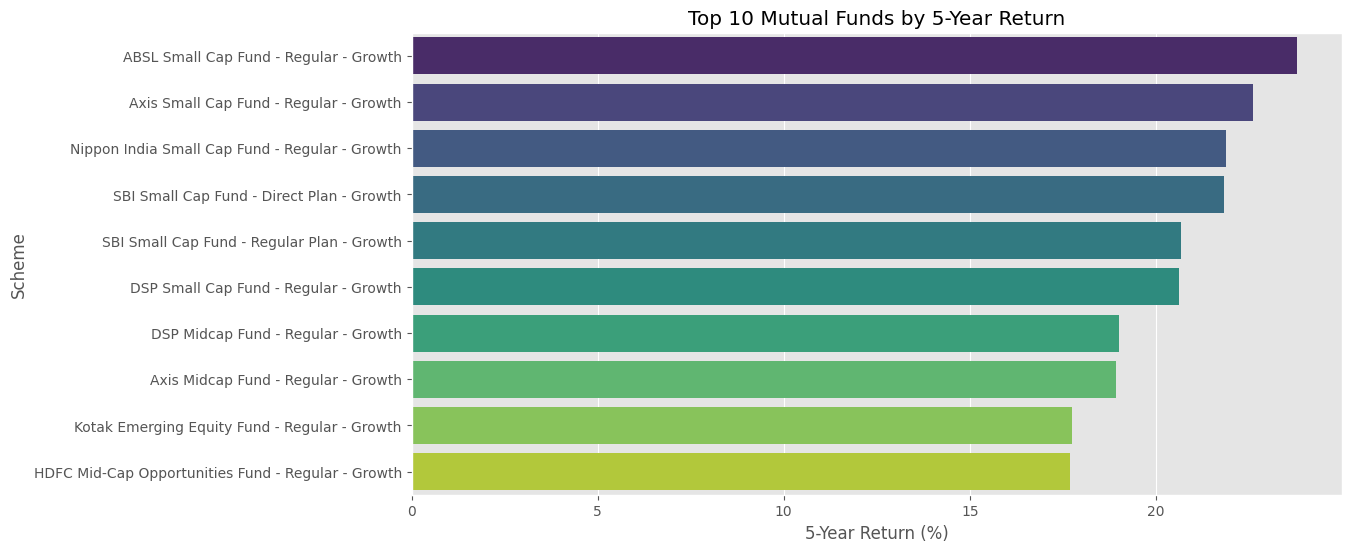

In [7]:
plt.figure(figsize=(12,6))

top_returns = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Mutual Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.show()

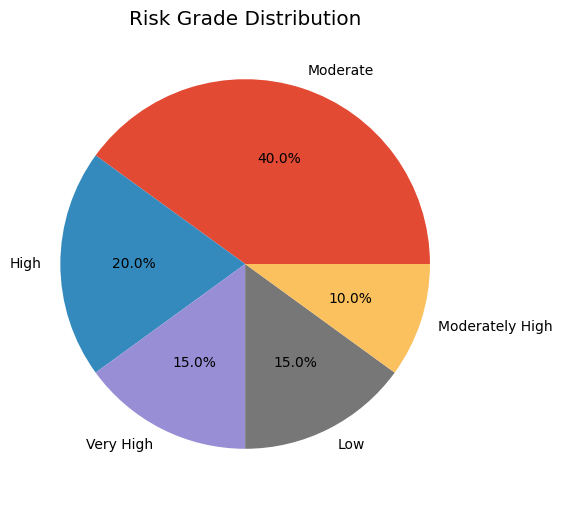

In [8]:
plt.figure(figsize=(8,6))

performance["risk_grade"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Risk Grade Distribution")
plt.ylabel("")

plt.show()

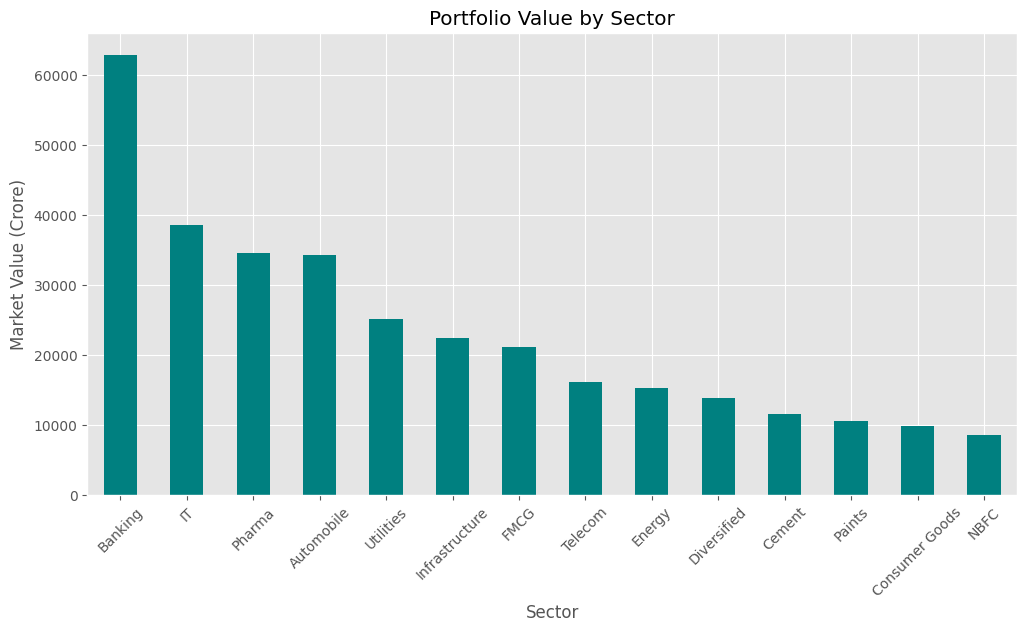

In [9]:
sector = (
    portfolio.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector.plot(kind="bar", color="teal")

plt.title("Portfolio Value by Sector")
plt.xlabel("Sector")
plt.ylabel("Market Value (Crore)")

plt.xticks(rotation=45)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1996\2757226560.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


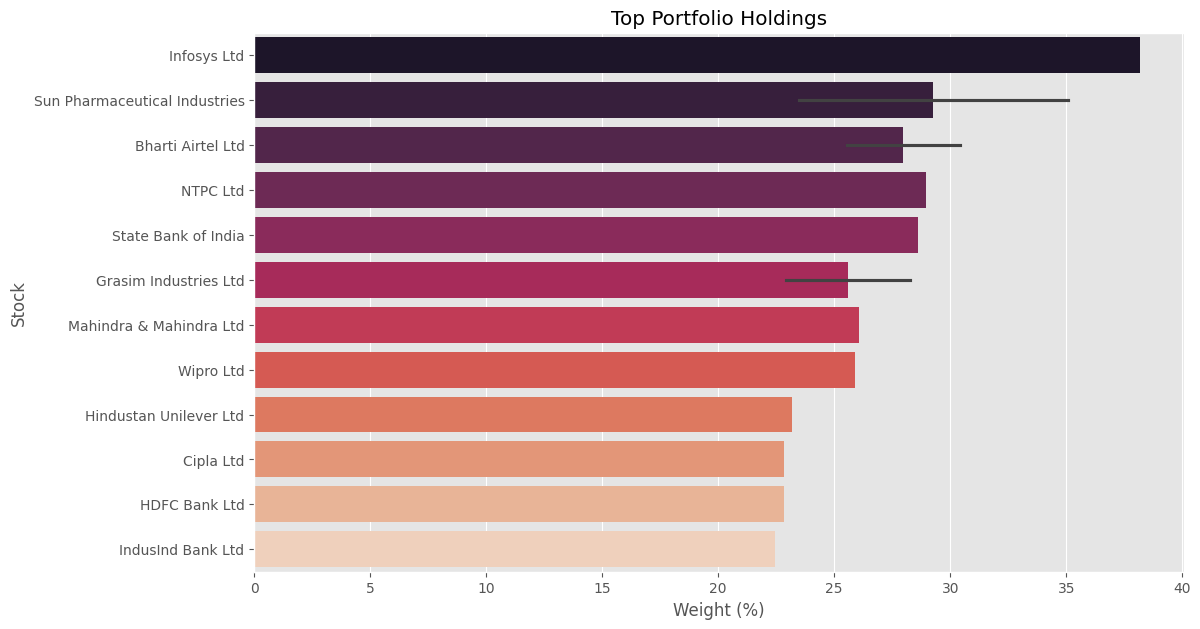

In [10]:
top_holdings = portfolio.sort_values(
    "weight_pct",
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_holdings,
    x="weight_pct",
    y="stock_name",
    palette="rocket"
)

plt.title("Top Portfolio Holdings")
plt.xlabel("Weight (%)")
plt.ylabel("Stock")

plt.show()

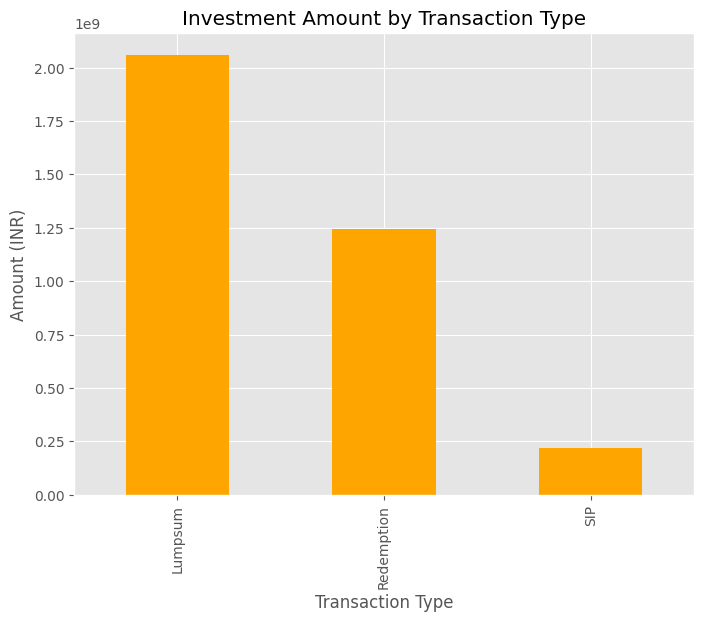

In [11]:
transactions.groupby("transaction_type")["amount_inr"] \
.sum() \
.plot(
    kind="bar",
    figsize=(8,6),
    color="orange"
)

plt.title("Investment Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (INR)")

plt.show()